In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzAz'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

print("✅ Environnement prêt")

✅ Environnement prêt


In [3]:
#| label: dirty-dataset
np.random.seed(42)
n = 300

dirty = pd.DataFrame({
    "id_client": range(1, n+1),
    "nom": np.random.choice(
        ["Alice Martin", "  alice martin ", "ALICE MARTIN", "Bob Dupont", "bob dupont"],
        size=n
    ),
    "age": np.random.randint(18, 85, n).astype(float),
    "salaire": np.random.normal(3500, 1000, n),
    "region": np.random.choice(["IDF", "  IDF ", "PACA", "paca", "ARA", None], n),
    "email": np.random.choice([
        "test@test.fr", "user@domain.com", "INVALID_EMAIL", "", None
    ], n),
    "nb_achats": np.random.poisson(5, n),
    "score_satisfaction": np.random.uniform(0, 10, n),
    "colonne_vide": [None] * n,  # colonne entièrement vide
    "pays": ["France"] * n       # colonne constante
})

# Injecter des pièges supplémentaires
dirty.loc[np.random.choice(n, 20), "age"] = np.nan               # NaN dispersés
dirty.loc[np.random.choice(n, 5), "age"] = 250                   # outliers
dirty.loc[np.random.choice(n, 10), "salaire"] = np.nan           # NaN
dirty.loc[0, "salaire"] = 1_000_000                              # outlier extrême
dirty.loc[1, "salaire"] = -500                                   # valeur incohérente
dirty.loc[np.random.choice(n, 8), "nb_achats"] = -1              # impossible
# Ajouter des doublons
doublons = dirty.sample(10, random_state=0)
dirty = pd.concat([dirty, doublons], ignore_index=True)

print(f"Dataset sale : {dirty.shape[0]} lignes x {dirty.shape[1]} colonnes")
dirty.head()

Dataset sale : 310 lignes x 10 colonnes


,id_client,nom,age,salaire,region,email,nb_achats,score_satisfaction,colonne_vide,pays
0,1,Bob Dupont,54.0,1000000.000000,ARA,user@domain.com,8,3.711129,None,France
1,2,bob dupont,41.0,-500.000000,PACA,test@test.fr,2,9.207666,None,France
2,3,ALICE MARTIN,63.0,3842.456918,paca,user@domain.com,7,5.844489,None,France
3,4,bob dupont,70.0,5411.529607,ARA,test@test.fr,9,5.383319,None,France
4,5,bob dupont,77.0,3819.537579,paca,test@test.fr,6,2.688535,None,France


In [4]:
def diagnostiquer(df):
    """Produit un rapport de diagnostic complet d'un DataFrame."""
    print("=" * 60)
    print(f"📊 DIAGNOSTIC — {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    print("=" * 60)
    
    # 1. Valeurs manquantes
    nan_counts = df.isna().sum()
    nan_pct = (nan_counts / len(df) * 100).round(2)
    nan_report = pd.DataFrame({
        "NaN": nan_counts,
        "% NaN": nan_pct
    })
    nan_report = nan_report[nan_report["NaN"] > 0].sort_values("NaN", ascending=False)
    
    if len(nan_report) > 0:
        print("\n🕳️  VALEURS MANQUANTES")
        print(nan_report)
    else:
        print("\n✅ Aucune valeur manquante")
    
    # 2. Doublons
    n_doublons = df.duplicated().sum()
    print(f"\n🔁 DOUBLONS : {n_doublons}")
    
    # 3. Colonnes constantes
    const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    if const_cols:
        print(f"\n📌 COLONNES CONSTANTES : {const_cols}")
    
    # 4. Types
    print("\n🏷️  TYPES")
    print(df.dtypes)
    
    # 5. Valeurs uniques pour les quali
    print("\n🔢 CARDINALITÉ")
    card = df.nunique().sort_values()
    print(card)

# Appliquer au dataset sale
diagnostiquer(dirty)

📊 DIAGNOSTIC — 310 lignes × 10 colonnes

🕳️  VALEURS MANQUANTES
              NaN   % NaN
colonne_vide  310  100.00
email          60   19.35
region         48   15.48
age            20    6.45
salaire        11    3.55

🔁 DOUBLONS : 10

📌 COLONNES CONSTANTES : ['colonne_vide', 'pays']

🏷️  TYPES
id_client               int64
nom                       str
age                   float64
salaire               float64
region                    str
email                     str
nb_achats               int32
score_satisfaction    float64
colonne_vide           object
pays                      str
dtype: object

🔢 CARDINALITÉ
colonne_vide            0
pays                    1
email                   4
nom                     5
region                  5
nb_achats              14
age                    68
salaire               290
score_satisfaction    300
id_client             300
dtype: int64


In [5]:
#| eval: false
# TODO: Exercice 1 — diagnostic + plan d'action

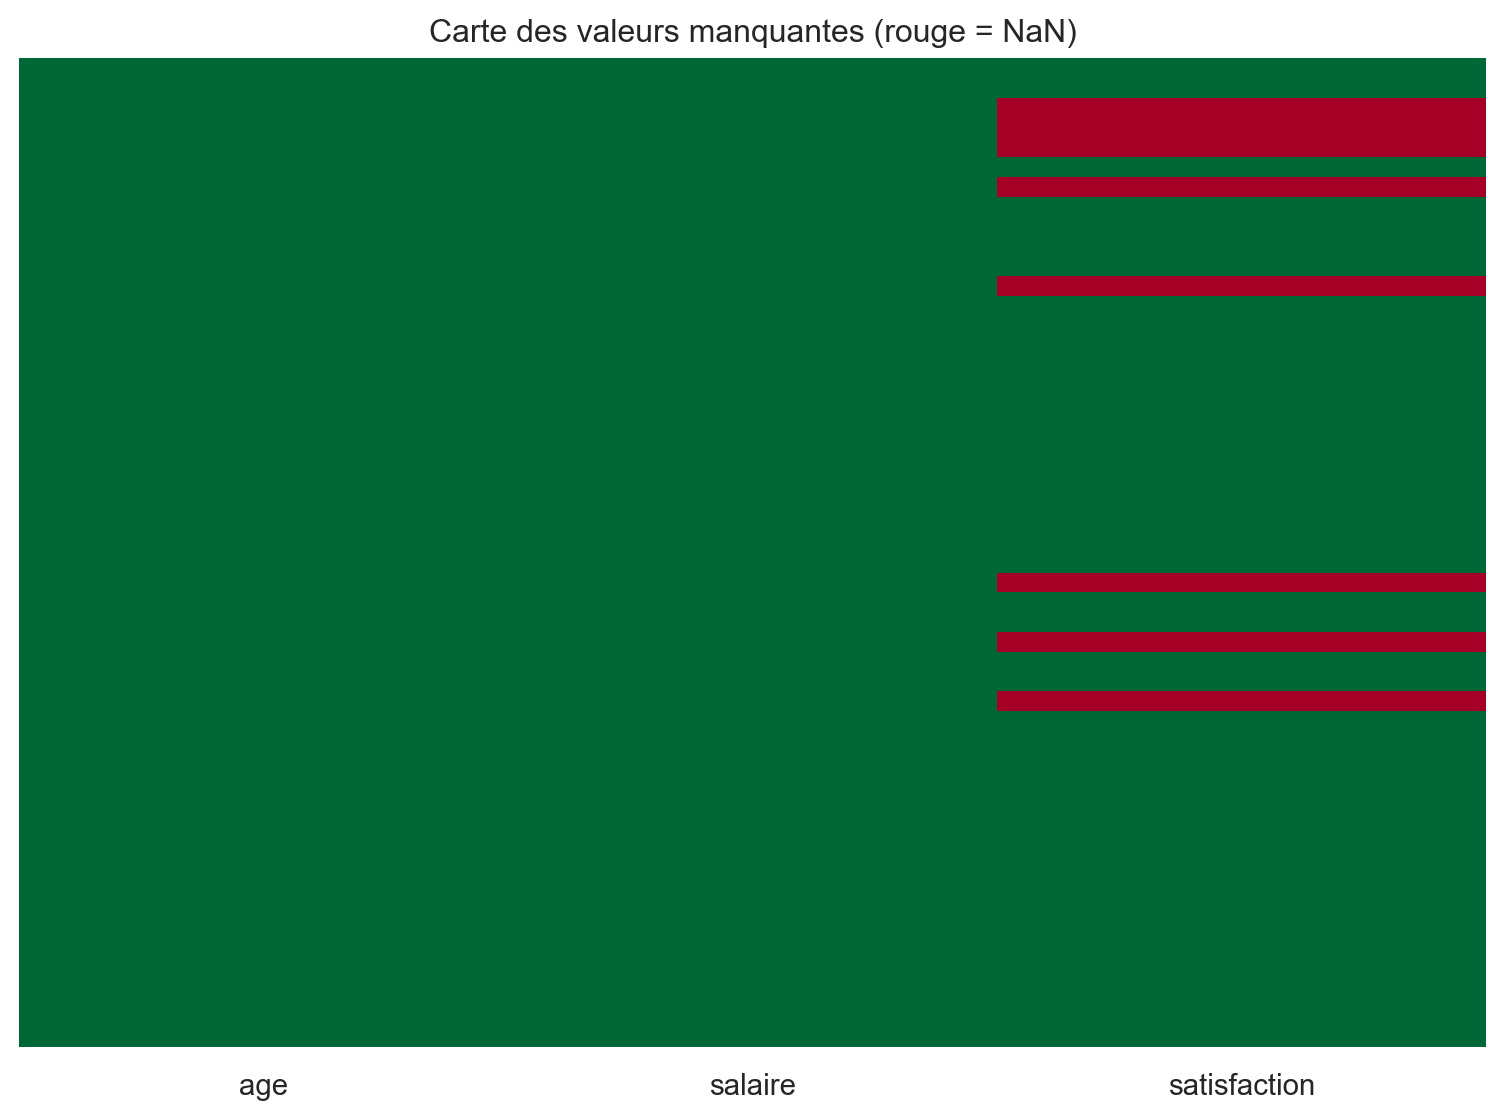

In [6]:
#| label: fig-nan-heatmap
#| fig-cap: Carte des valeurs manquantes

# Créer un mini-dataset avec un pattern de NaN non-aléatoire
np.random.seed(0)
nm = pd.DataFrame({
    "age": np.random.randint(20, 70, 50),
    "salaire": np.random.normal(3000, 800, 50),
    "satisfaction": np.random.uniform(1, 10, 50),
})

# Les personnes jeunes ne répondent pas à satisfaction (MAR)
nm.loc[nm["age"] < 30, "satisfaction"] = np.where(
    np.random.random((nm["age"] < 30).sum()) < 0.7,
    np.nan, nm.loc[nm["age"] < 30, "satisfaction"]
)

# Carte thermique des NaN
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(nm.isna(), cbar=False, cmap="RdYlGn_r", ax=ax, 
            yticklabels=False)
ax.set_title("Carte des valeurs manquantes (rouge = NaN)")
plt.tight_layout()
plt.show()

In [7]:
df = dirty.copy()

# Supprimer la colonne entièrement vide
df = df.drop(columns=["colonne_vide", "pays"])

# Stratégies différentes selon la variable
# age : médiane (distribution possiblement asymétrique)
df["age"] = df["age"].fillna(df["age"].median())

# salaire : on impute par la médiane, mais on traite d'abord les outliers !
# (si on impute par la moyenne avec un outlier à 1M, la moyenne sera faussée)
df["salaire"] = df["salaire"].fillna(df["salaire"].median())

# region : mode
df["region"] = df["region"].fillna(df["region"].mode()[0])

# email : "Inconnu" (catégoriel avec beaucoup de cas particuliers)
df["email"] = df["email"].fillna("Inconnu")

print("NaN restants :")
print(df.isna().sum())

NaN restants :
id_client             0
nom                   0
age                   0
salaire               0
region                0
email                 0
nb_achats             0
score_satisfaction    0
dtype: int64


In [8]:
# Exemple : imputer l'âge par la médiane DE LA RÉGION
# (si l'âge moyen varie par région, c'est plus précis)

# Recréer quelques NaN pour la démo
df_demo = dirty.copy()
df_demo["region"] = df_demo["region"].fillna("Inconnu")

# Imputation conditionnelle par groupe
df_demo["age_imputed"] = df_demo.groupby("region", observed=True)["age"].transform(
    lambda x: x.fillna(x.median())
)
print("✅ Imputation conditionnelle effectuée")
print(f"Age moyen imputé par région :")
print(df_demo.groupby("region", observed=True)["age_imputed"].median())

✅ Imputation conditionnelle effectuée
Age moyen imputé par région :
region
  IDF      57.0
ARA        50.5
IDF        50.0
Inconnu    54.5
PACA       46.0
paca       53.0
Name: age_imputed, dtype: float64


In [9]:
from sklearn.impute import KNNImputer

# On ne l'applique que sur les variables numériques
df_num = dirty[["age", "salaire", "nb_achats", "score_satisfaction"]].copy()

imputer = KNNImputer(n_neighbors=5)
df_num_imputed = pd.DataFrame(
    imputer.fit_transform(df_num),
    columns=df_num.columns
)

print(f"NaN avant : {df_num.isna().sum().sum()}")
print(f"NaN après : {df_num_imputed.isna().sum().sum()}")

NaN avant : 31
NaN après : 0


In [10]:
#| eval: false
# TODO: Exercice 2

In [11]:
np.random.seed(0)
n = 200
banque = pd.DataFrame({
    "age": np.random.randint(18, 80, n).astype(float),
    "salaire": np.random.normal(3000, 1000, n),
    "nb_operations": np.random.poisson(20, n),
    "segment": np.random.choice(["Jeune", "Actif", "Senior"], n, p=[0.3, 0.5, 0.2])
})
idx_seniors = banque[banque["segment"] == "Senior"].index
idx_a_nuller = np.random.choice(idx_seniors, size=int(len(idx_seniors) * 0.6), replace=False)
banque.loc[idx_a_nuller, "salaire"] = np.nan
banque.loc[np.random.choice(n, 10, replace=False), "age"] = np.nan

In [12]:
# 1. Diagnostic
diagnostiquer(banque)

📊 DIAGNOSTIC — 200 lignes × 4 colonnes

🕳️  VALEURS MANQUANTES
         NaN  % NaN
salaire   21   10.5
age       10    5.0

🔁 DOUBLONS : 0

🏷️  TYPES
age              float64
salaire          float64
nb_operations      int32
segment              str
dtype: object

🔢 CARDINALITÉ
segment            3
nb_operations     24
age               56
salaire          179
dtype: int64


In [13]:
# 2. % de NaN par segment pour salaire
pct_nan = banque.groupby("segment", observed=True)["salaire"].apply(
    lambda x: x.isna().mean() * 100
).round(1)
print("% de NaN sur salaire par segment :")
print(pct_nan)

% de NaN sur salaire par segment :
segment
Actif      0.0
Jeune      0.0
Senior    58.3
Name: salaire, dtype: float64


In [14]:
# 3. age : médiane globale (MCAR)
banque["age"] = banque["age"].fillna(banque["age"].median())

# 4. salaire : médiane par segment (MAR)
banque["salaire"] = banque.groupby("segment", observed=True)["salaire"].transform(
    lambda x: x.fillna(x.median())
)

# 5. Vérification
print(f"\n✅ NaN restants : {banque.isna().sum().sum()}")


✅ NaN restants : 0


In [15]:
def outliers_iqr(serie, coef=1.5):
    """Retourne un masque booléen des outliers."""
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    return (serie < q1 - coef*iqr) | (serie > q3 + coef*iqr)

# Sur notre dataset sale
outliers_salaire = outliers_iqr(dirty["salaire"])
print(f"Outliers salaire (IQR) : {outliers_salaire.sum()}")

Outliers salaire (IQR) : 5


In [16]:
def outliers_zscore(serie, seuil=3):
    """Détection par z-score."""
    z = (serie - serie.mean()) / serie.std()
    return z.abs() > seuil

outliers_z = outliers_zscore(dirty["salaire"])
print(f"Outliers salaire (z-score) : {outliers_z.sum()}")

Outliers salaire (z-score) : 1


In [17]:
def outliers_percentiles(serie, low=1, high=99):
    """Détection par bornes percentiles."""
    borne_basse = serie.quantile(low / 100)
    borne_haute = serie.quantile(high / 100)
    return (serie < borne_basse) | (serie > borne_haute)

outliers_p = outliers_percentiles(dirty["salaire"], low=1, high=99)
print(f"Outliers salaire (1% / 99%) : {outliers_p.sum()}")

Outliers salaire (1% / 99%) : 6


In [18]:
# Pour le salaire : 
# - un salaire négatif est impossible
# - un salaire > 1 million est très suspect

outliers_metier = (dirty["salaire"] < 0) | (dirty["salaire"] > 500_000)
print(f"Outliers salaire (métier) : {outliers_metier.sum()}")

Outliers salaire (métier) : 3


In [19]:
# Radical mais efficace
df_sans = dirty[~outliers_metier].copy()
print(f"Avant : {len(dirty)}, Après : {len(df_sans)}")

Avant : 310, Après : 307


In [20]:
df_capped = dirty.copy()

# Borne supérieure : 99e percentile
borne_sup = df_capped["salaire"].quantile(0.99)
# Borne inférieure : minimum raisonnable (métier)
borne_inf = 0  # salaire ne peut pas être < 0

df_capped["salaire"] = df_capped["salaire"].clip(lower=borne_inf, upper=borne_sup)
print(f"Min salaire : {df_capped['salaire'].min():.0f}")
print(f"Max salaire : {df_capped['salaire'].max():.0f}")

Min salaire : 0
Max salaire : 6074


In [21]:
df_replaced = dirty.copy()
mask = outliers_metier.reindex(df_replaced.index, fill_value=False)
df_replaced.loc[mask, "salaire"] = np.nan

# Puis imputer
df_replaced["salaire"] = df_replaced["salaire"].fillna(df_replaced["salaire"].median())
print(f"✅ {mask.sum()} outliers remplacés puis imputés")

✅ 3 outliers remplacés puis imputés


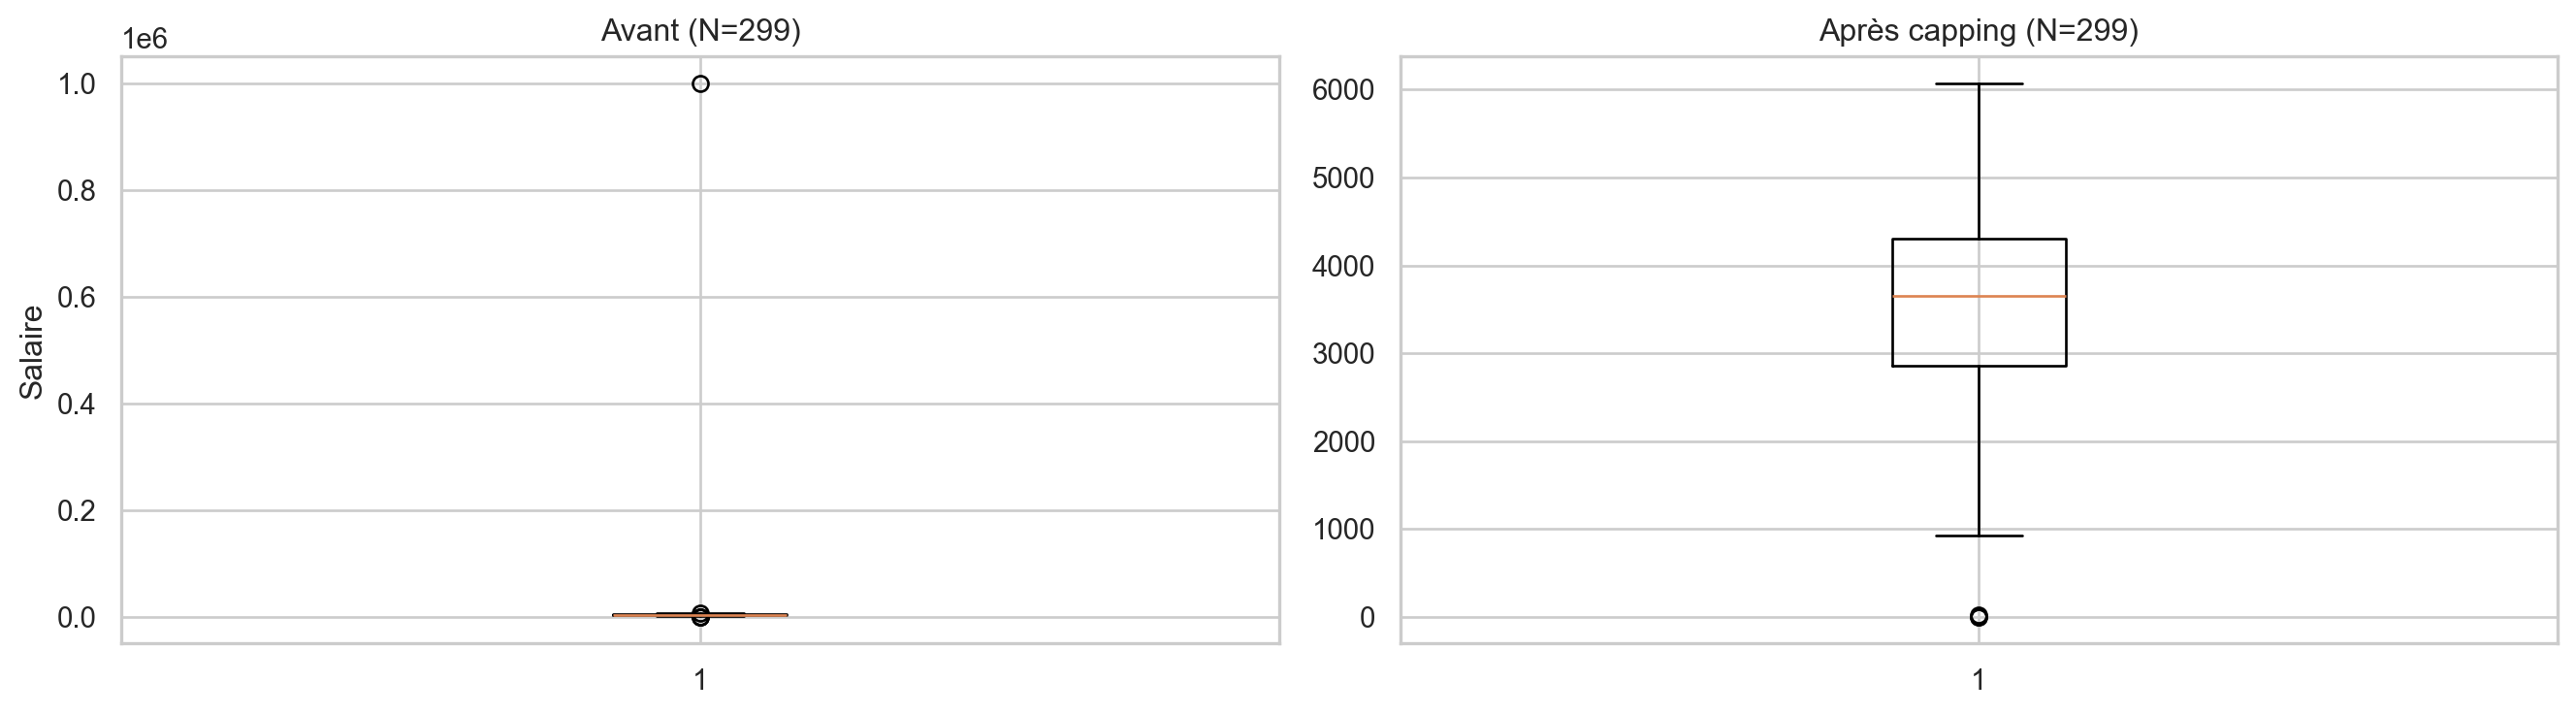

In [22]:
#| label: fig-outliers-before-after
#| fig-cap: Avant / après traitement des outliers

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Avant
salaire_clean = dirty["salaire"].dropna()
axes[0].boxplot(salaire_clean)
axes[0].set_title(f"Avant (N={len(salaire_clean)})")
axes[0].set_ylabel("Salaire")

# Après capping
salaire_capped = df_capped["salaire"].dropna()
axes[1].boxplot(salaire_capped)
axes[1].set_title(f"Après capping (N={len(salaire_capped)})")

plt.tight_layout()
plt.show()

In [23]:
#| eval: false
# TODO: Exercice 3

In [24]:
# 1. Age : IQR
out_age = outliers_iqr(dirty["age"])
print(f"Outliers age (IQR) : {out_age.sum()}")

Outliers age (IQR) : 5


In [25]:
# 2. nb_achats : métier
out_achats = dirty["nb_achats"] < 0
print(f"nb_achats négatifs : {out_achats.sum()}")

nb_achats négatifs : 9


In [26]:
# 3. Comparaison des méthodes sur salaire
out_iqr = outliers_iqr(dirty["salaire"])
out_z = outliers_zscore(dirty["salaire"])
out_p = outliers_percentiles(dirty["salaire"], 1, 99)

print(f"IQR         : {out_iqr.sum()}")
print(f"Z-score     : {out_z.sum()}")
print(f"Percentiles : {out_p.sum()}")

IQR         : 5
Z-score     : 1
Percentiles : 6


In [27]:
# 4. Capping age
df = dirty.copy()
df["age"] = df["age"].clip(lower=18, upper=100)
print(f"Min age : {df['age'].min()}")
print(f"Max age : {df['age'].max()}")

Min age : 18.0
Max age : 100.0


In [28]:
# 5. Nb_achats négatifs à 0
df.loc[df["nb_achats"] < 0, "nb_achats"] = 0
print(f"Min nb_achats : {df['nb_achats'].min()}")

Min nb_achats : 0


In [29]:
n_parfaits = dirty.duplicated().sum()
print(f"Doublons parfaits : {n_parfaits}")

Doublons parfaits : 10


In [30]:
# Vérifier les doublons sur id_client
n_clients_dup = dirty.duplicated(subset=["id_client"]).sum()
print(f"Clients dupliqués (même id_client) : {n_clients_dup}")

Clients dupliqués (même id_client) : 10


In [31]:
# Sur la colonne 'nom' de notre dataset sale
print("Valeurs uniques de 'nom' (6 premières) :")
print(dirty["nom"].unique()[:6])

Valeurs uniques de 'nom' (6 premières) :
<StringArray>
['Bob Dupont', 'bob dupont', 'ALICE MARTIN', '  alice martin ',
 'Alice Martin']
Length: 5, dtype: str


In [32]:
# Stratégie : normaliser AVANT de dédupliquer
df = dirty.copy()

# 1. Normaliser le champ nom
df["nom_normalise"] = (
    df["nom"].str.strip()              # retire espaces en début/fin
             .str.lower()              # tout en minuscules
             .str.title()              # majuscules en début de mots
)

# Maintenant la déduplication devient possible
print("Valeurs uniques après normalisation :")
print(df["nom_normalise"].unique()[:6])

Valeurs uniques après normalisation :
<StringArray>
['Bob Dupont', 'Alice Martin']
Length: 2, dtype: str


In [33]:
# Exemple : même commande (client + date + produit)
# Si 2 lignes ont les 3 mêmes valeurs, c'est un doublon métier

df_cmd = pd.DataFrame({
    "id_client": [1, 1, 2, 3, 1],
    "date": ["2024-01-01", "2024-01-01", "2024-01-02", "2024-01-03", "2024-01-01"],
    "produit": ["A", "A", "B", "C", "A"],
    "montant": [100, 100, 50, 200, 100],
})

# Déduplication sur (client, date, produit)
df_cmd_clean = df_cmd.drop_duplicates(subset=["id_client", "date", "produit"], keep="first")
print(f"Avant : {len(df_cmd)}, Après : {len(df_cmd_clean)}")

Avant : 5, Après : 3


In [34]:
# Un échantillon de textes sales
textes = pd.Series([
    "  Paris  ",
    "PARIS",
    "paris",
    "Pariis",
    "Marseille\t",
    "marseille ",
    "MARSEILLE",
    "lyon",
])

# 1. strip() : retire les espaces en début/fin
print("strip     :", textes.str.strip().unique())

# 2. lower() : tout en minuscules
print("\nlower     :", textes.str.lower().unique())

# 3. upper() : tout en majuscules
print("\nupper     :", textes.str.upper().unique())

# 4. title() : première lettre de chaque mot en majuscule
print("\ntitle     :", textes.str.title().unique())

# 5. replace() : remplacement classique
print("\nreplace   :", textes.str.replace(r'\s+', ' ', regex=True).unique())

strip     : <StringArray>
[    'Paris',     'PARIS',     'paris',    'Pariis', 'Marseille', 'marseille',
 'MARSEILLE',      'lyon']
Length: 8, dtype: str

lower     : <StringArray>
[  '  paris  ',       'paris',      'pariis', 'marseille\t',  'marseille ',
   'marseille',        'lyon']
Length: 7, dtype: str

upper     : <StringArray>
[  '  PARIS  ',       'PARIS',      'PARIIS', 'MARSEILLE\t',  'MARSEILLE ',
   'MARSEILLE',        'LYON']
Length: 7, dtype: str

title     : <StringArray>
[  '  Paris  ',       'Paris',      'Pariis', 'Marseille\t',  'Marseille ',
   'Marseille',        'Lyon']
Length: 7, dtype: str

replace   : <StringArray>
[   ' Paris ',      'PARIS',      'paris',     'Pariis', 'Marseille ',
 'marseille ',  'MARSEILLE',       'lyon']
Length: 8, dtype: str


In [35]:
def normaliser_texte(serie):
    """Normalise une série de textes de manière complète."""
    return (
        serie
        .astype(str)
        .str.strip()                         # retire espaces début/fin
        .str.replace(r'\s+', ' ', regex=True) # remplace multi-espaces par un seul
        .str.lower()                         # tout en minuscules
    )

# Application
textes_clean = normaliser_texte(textes)
print(f"Avant : {textes.nunique()} valeurs uniques")
print(f"Après : {textes_clean.nunique()} valeurs uniques")
print("Valeurs :", textes_clean.unique())

Avant : 8 valeurs uniques
Après : 4 valeurs uniques
Valeurs : <StringArray>
['paris', 'pariis', 'marseille', 'lyon']
Length: 4, dtype: str


In [36]:
# Exemple : valider des emails
emails = pd.Series([
    "user@domain.com",
    "INVALID_EMAIL",
    "other.user@example.fr",
    "wrong@",
    "@domain.com",
    "",
    "good.email+tag@company.co.uk"
])

# Pattern simple pour un email valide
pattern_email = r"^[\w\.\+-]+@[\w-]+\.[\w\.-]+$"
is_valid = emails.str.match(pattern_email, na=False)

# Afficher le résultat
resultat = pd.DataFrame({"email": emails, "valide": is_valid})
print(resultat)

                          email  valide
0               user@domain.com    True
1                 INVALID_EMAIL   False
2         other.user@example.fr    True
3                        wrong@   False
4                   @domain.com   False
5                                 False
6  good.email+tag@company.co.uk    True


In [37]:
#| eval: false
# TODO: Exercice 4

In [38]:
df = dirty.copy()

# 1. nom
df["nom_clean"] = df["nom"].str.strip().str.lower().str.title()

# 2. region — gérer les NaN
df["region_clean"] = (
    df["region"]
    .fillna("Inconnue")
    .str.strip()
    .str.upper()
)

# 3. Uniques avant/après
print(f"region avant  : {dirty['region'].nunique(dropna=False)} valeurs uniques")
print(f"region après  : {df['region_clean'].nunique()} valeurs uniques")
print(f"Valeurs : {df['region_clean'].unique()}")

region avant  : 6 valeurs uniques
region après  : 4 valeurs uniques
Valeurs : <StringArray>
['ARA', 'PACA', 'IDF', 'INCONNUE']
Length: 4, dtype: str


In [39]:
# 4-5. Validation des emails
pattern_email = r"^[\w\.\+-]+@[\w-]+\.[\w\.-]+$"
df["email_valide"] = df["email"].str.match(pattern_email, na=False)

pct_invalide = (~df["email_valide"]).mean() * 100
print(f"% d'emails invalides : {pct_invalide:.1f}%")

% d'emails invalides : 59.7%


In [40]:
#| eval: false
# TODO: Exercice bilan — pipeline complet

In [41]:
def nettoyer_dataset(df):
    """
    Pipeline de nettoyage complet.
    
    Paramètres
    ----------
    df : pd.DataFrame
        Dataset à nettoyer
    
    Retour
    ------
    df_clean : pd.DataFrame
        Dataset nettoyé
    rapport : dict
        Bilan des actions effectuées
    """
    rapport = {}
    df = df.copy()  # ne pas modifier l'original
    
    # 1. Colonnes inutiles
    cols_vides = [c for c in df.columns if df[c].isna().all()]
    cols_const = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    cols_a_suppr = list(set(cols_vides + cols_const))
    df = df.drop(columns=cols_a_suppr)
    rapport["colonnes_supprimees"] = cols_a_suppr
    
    # 2. Doublons parfaits
    n_avant = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    rapport["doublons_supprimes"] = n_avant - len(df)
    
    # 3. Normalisation textes
    if "nom" in df.columns:
        df["nom"] = df["nom"].str.strip().str.lower().str.title()
    if "region" in df.columns:
        df["region"] = (
            df["region"].fillna("Inconnue").str.strip().str.upper()
        )
    rapport["textes_normalises"] = ["nom", "region"]
    
    # 4. Capping outliers
    if "age" in df.columns:
        df["age"] = df["age"].clip(lower=18, upper=100)
    if "salaire" in df.columns:
        borne_sup = df["salaire"].quantile(0.99)
        df["salaire"] = df["salaire"].clip(lower=0, upper=borne_sup)
    rapport["outliers_cappes"] = ["age (18-100)", f"salaire (0-{borne_sup:.0f})"]
    
    # 5. Valeurs métier incohérentes
    if "nb_achats" in df.columns:
        n_neg = (df["nb_achats"] < 0).sum()
        df.loc[df["nb_achats"] < 0, "nb_achats"] = 0
        rapport["nb_achats_corriges"] = int(n_neg)
    
    # 6. Imputation
    nan_avant = df.isna().sum().sum()
    if "age" in df.columns:
        df["age"] = df["age"].fillna(df["age"].median())
    if "salaire" in df.columns:
        df["salaire"] = df["salaire"].fillna(df["salaire"].median())
    if "region" in df.columns:
        df["region"] = df["region"].fillna("Inconnue")
    if "email" in df.columns:
        df["email"] = df["email"].fillna("Inconnu")
    nan_apres = df.isna().sum().sum()
    rapport["nan_imputes"] = int(nan_avant - nan_apres)
    rapport["nan_restants"] = int(nan_apres)
    
    # Stats finales
    rapport["taille_finale"] = df.shape
    
    return df, rapport


# Appel
df_clean, rapport = nettoyer_dataset(dirty)

print("=" * 50)
print("📋 RAPPORT DE NETTOYAGE")
print("=" * 50)
for cle, valeur in rapport.items():
    print(f"{cle:28s} : {valeur}")

print(f"\n✅ Dataset nettoyé : {df_clean.shape}")
print(f"✅ NaN restants    : {df_clean.isna().sum().sum()}")

📋 RAPPORT DE NETTOYAGE
colonnes_supprimees          : ['colonne_vide', 'pays']
doublons_supprimes           : 10
textes_normalises            : ['nom', 'region']
outliers_cappes              : ['age (18-100)', 'salaire (0-6078)']
nb_achats_corriges           : 8
nan_imputes                  : 87
nan_restants                 : 0
taille_finale                : (300, 8)

✅ Dataset nettoyé : (300, 8)
✅ NaN restants    : 0
